In [22]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import textwrap


from dotenv import load_dotenv
load_dotenv()

from pathlib import Path

# add project root to Python path
sys.path.append(str(Path().resolve().parent))

In [23]:
from spectral_code.preprocessing.cleaner import clean_and_compose_graphs
from spectral_code.spectral.extractor import extract_all_spectral_features

In [24]:
BASE_DIR = os.getenv("BASE_DIR")

RAW_FEATURES_DIR = os.path.join(BASE_DIR, "outputs", "dataset_features")
TIMING_FILE = os.path.join(BASE_DIR, "outputs", "timing_stats.json")

print("[*] Generating Cleaned Graphs Dataset Live via Modular Pipeline...")
BASE_LAYERS = ["ast", "cfg", "ddg", "pdg"]

# Live processing a subset of 250 methods (to save RAM in notebook) using the clean_and_compose_graphs function
graph_db, methods_cleaned, layers_cleaned = clean_and_compose_graphs(RAW_FEATURES_DIR, BASE_LAYERS, limit=250)

print(f"[+] Multi-layer graph loaded successfully! Valid methods loaded: {methods_cleaned}")

print("\n[*] Extracting Spectral Features Live using Modular Extractor...")
# Utilizing the same extractor architecture as extract_spectral_features.py
features_db, layer_counts, layer_durations, layer_node_sums = extract_all_spectral_features(graph_db, BASE_LAYERS)

print(f"[+] Spectral features perfectly extracted for {len(features_db)} methods!")

valid_anchors = list(graph_db.keys())
random_method_id = random.choice(valid_anchors)
print(f"\n[+] Global Anchor Method ID selected for profiling: {random_method_id}")

[*] Generating Cleaned Graphs Dataset Live via Modular Pipeline...


Cleaning & Composing Directed Layers: 100%|██████████| 250/250 [00:04<00:00, 53.80it/s]


[+] Multi-layer graph loaded successfully! Valid methods loaded: 250

[*] Extracting Spectral Features Live using Modular Extractor...


Processing Methods: 100%|██████████| 250/250 [00:04<00:00, 57.46it/s]

[+] Spectral features perfectly extracted for 250 methods!

[+] Global Anchor Method ID selected for profiling: 10095821


In [25]:
DATA_DIR = Path("data")

JSONL_PATH = BASE_DIR / DATA_DIR / "data.jsonl"
TRAIN_PATH = BASE_DIR / DATA_DIR / "train.txt"

code_map = {}

with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        code_map[item["idx"]] = item["func"]

train_pairs = []

with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    for line in f:
        i1, i2, label = line.strip().split()
        train_pairs.append((str(i1), str(i2), int(label)))

In [53]:
from pygments import highlight
from pygments.lexers import JavaLexer
from pygments.formatters import ImageFormatter
from PIL import Image
import io


def render_code_image(
    code,
    font_size=20,
    line_numbers=True,
    style="monokai",
):
    """
    High-quality IntelliJ-like Java code rendering.
    """

    formatter = ImageFormatter(
        font_name="Consolas",

        # QUALITY
        font_size=font_size,
        image_pad=30,
        line_pad=6,

        # LINE NUMBERS
        line_numbers=line_numbers,
        line_number_pad=12,
        line_number_bg="#272822",
        line_number_fg="#909090",

        # STYLE
        style=style,

        # HIGH DPI RENDERING
        dpi=300,

        # BETTER SPACING
        hl_lines=[],
    )

    img_data = highlight(
        code,
        JavaLexer(),
        formatter,
    )

    img = Image.open(io.BytesIO(img_data))

    return img

GRAPH_COLORS = {
    "ast": "#1ABC9C",
    "cfg": "#3498DB",
    "ddg": "#E67E22",
    "pdg": "#9B59B6",
}


def get_random_valid_pair(train_pairs, graph_db, features_db):
    """
    Randomly select a valid pair where both methods
    exist in graph_db and features_db.
    """
    while True:
        idx1, idx2, label = random.choice(train_pairs)

        if (
            idx1 in graph_db
            and idx2 in graph_db
            and idx1 in features_db
            and idx2 in features_db
        ):
            return idx1, idx2, label


def draw_graph(ax, G, title, color="#3498db", node_limit=150):
    """
    Draw a graph safely with layout selection based on size.
    """
    if G is None or G.number_of_nodes() == 0:
        ax.text(
            0.5,
            0.5,
            "[Empty Graph]",
            ha="center",
            va="center",
            fontsize=11,
            color="gray",
        )
        ax.set_axis_off()
        return

    num_nodes = G.number_of_nodes()

    try:
        if num_nodes <= node_limit:
            pos = nx.spring_layout(G, seed=42, k=0.4)
            node_size = 40
            edge_width = 0.8
        else:
            pos = nx.circular_layout(G)
            node_size = 15
            edge_width = 0.4

        nx.draw(
            G,
            pos,
            ax=ax,
            node_size=node_size,
            node_color=color,
            edge_color="#95a5a6",
            width=edge_width,
            with_labels=False,
            arrows=True,
            arrowsize=6,
        )

        ax.set_title(
            f"{title}\nNodes={num_nodes} | Edges={G.number_of_edges()}",
            fontsize=10,
        )

    except Exception as e:
        ax.text(
            0.5,
            0.5,
            f"[Visualization Error]\n{str(e)}",
            ha="center",
            va="center",
        )

    ax.set_axis_off()


def plot_spectral_signatures(ax, ev1, ev2, layer_name):
    """
    Plot sorted eigenvalue signatures.
    """
    ev1 = np.sort(np.array(ev1))
    ev2 = np.sort(np.array(ev2))

    ax.plot(
        ev1,
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="Method 1",
    )

    ax.plot(
        ev2,
        marker="x",
        markersize=3,
        linewidth=1.5,
        label="Method 2",
    )

    ax.set_title(f"{layer_name.upper()} Spectrum", fontsize=11)
    ax.set_xlabel("Eigenvalue Index")
    ax.set_ylabel("λ")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()


def visualize_method_pair(
    idx1,
    idx2,
    label,
    graph_db,
    features_db,
    code_map,
    graph_layers=("ast", "cfg", "ddg"),
):
    """
    Full visualization:
    - source codes
    - graph structures
    - spectral signatures
    """

    fig = plt.figure(figsize=(26, 20))

    gs = fig.add_gridspec(
        nrows=4,
        ncols=3,
        height_ratios=[2.5, 1.5, 1.5, 1.5],
    )

    # =========================================================
    # SOURCE CODE (IDE STYLE)
    # =========================================================

    code_ax1 = fig.add_subplot(gs[0, 0])
    code_ax2 = fig.add_subplot(gs[0, 1])
    meta_ax = fig.add_subplot(gs[0, 2])

    code1 = code_map.get(idx1, "// Code Missing")
    code2 = code_map.get(idx2, "// Code Missing")

    # truncate extremely large methods
    MAX_CHARS = 4000
    code1 = code1[:MAX_CHARS]
    code2 = code2[:MAX_CHARS]

    img1 = render_code_image(code1)
    img2 = render_code_image(code2)

    code_ax1.imshow(img1)
    code_ax2.imshow(img2)

    code_ax1.set_title(
        f"Method 1: {idx1}",
        fontsize=12,
        weight="bold",
    )

    code_ax2.set_title(
        f"Method 2: {idx2}",
        fontsize=12,
        weight="bold",
    )

    code_ax1.axis("off")
    code_ax2.axis("off")

    label_text = (
        "Semantic Clone Pair"
        if label == 1
        else "Non-Clone Pair"
    )

    meta_ax.text(
        0.05,
        0.7,
        f"PAIR LABEL: {label}\n\n{label_text}",
        fontsize=16,
        weight="bold",
    )

    meta_ax.axis("off")

    # =========================================================
    # GRAPH VISUALIZATION
    # =========================================================

    for i, layer in enumerate(graph_layers):

        g1 = graph_db[idx1].get(layer)
        g2 = graph_db[idx2].get(layer)

        ax1 = fig.add_subplot(gs[1, i])
        ax2 = fig.add_subplot(gs[2, i])

        draw_graph(
            ax1,
            g1,
            f"M1 - {layer.upper()}",
            color=GRAPH_COLORS.get(layer, "#3498db"),
        )

        draw_graph(
            ax2,
            g2,
            f"M2 - {layer.upper()}",
            color=GRAPH_COLORS.get(layer, "#e74c3c"),
        )

    # =========================================================
    # SPECTRAL SIGNATURES
    # =========================================================

    for i, layer in enumerate(graph_layers):

        ax = fig.add_subplot(gs[3, i])

        ev1 = (
            features_db[idx1]
            .get(layer, {})
            .get("eigenvalues", [])
        )

        ev2 = (
            features_db[idx2]
            .get(layer, {})
            .get("eigenvalues", [])
        )

        plot_spectral_signatures(ax, ev1, ev2, layer)

    fig.suptitle(
        f"Graph + Spectral Comparison\n"
        f"Method Pair: ({idx1}, {idx2}) | Label={label}",
        fontsize=20,
        weight="bold",
    )

    plt.tight_layout()
    plt.show()


def visualize_random_pair(
    train_pairs,
    graph_db,
    features_db,
    code_map,
):
    """
    Convenience wrapper:
    randomly choose a valid pair and visualize it.
    """

    idx1, idx2, label = get_random_valid_pair(
        train_pairs,
        graph_db,
        features_db,
    )

    print("=" * 80)
    print(f"Selected Pair")
    print(f"Method 1: {idx1}")
    print(f"Method 2: {idx2}")
    print(f"Label    : {label}")
    print("=" * 80)

    visualize_method_pair(
        idx1,
        idx2,
        label,
        graph_db,
        features_db,
        code_map,
    )

In [54]:
def describe_graph(G):
    print("=" * 60)

    print(f"Graph Type         : {type(G).__name__}")
    print(f"Directed           : {G.is_directed()}")
    print(f"Nodes              : {G.number_of_nodes()}")
    print(f"Edges              : {G.number_of_edges()}")

    if G.number_of_nodes() > 0:
        degrees = [d for _, d in G.degree()]

        print(f"Density            : {nx.density(G):.6f}")
        print(f"Average Degree     : {np.mean(degrees):.2f}")
        print(f"Max Degree         : {np.max(degrees)}")
        print(f"Min Degree         : {np.min(degrees)}")
        print(f"Self Loops         : {nx.number_of_selfloops(G)}")

        if G.is_directed():
            print(f"Weakly Connected   : {nx.is_weakly_connected(G)}")
            print(f"# Weak Components  : {nx.number_weakly_connected_components(G)}")
        else:
            print(f"Connected          : {nx.is_connected(G)}")
            print(f"# Components       : {nx.number_connected_components(G)}")

    print("=" * 60)

In [55]:
G1 = graph_db['10013939']['cfg']
G2 = graph_db['10298747']['cfg']
describe_graph(G1)
describe_graph(G2)
# Method 1: 10013939
# Method 2: 10298747

Graph Type         : DiGraph
Directed           : True
Nodes              : 38
Edges              : 43
Density            : 0.030583
Average Degree     : 2.26
Max Degree         : 5
Min Degree         : 1
Self Loops         : 0
Weakly Connected   : True
# Weak Components  : 1
Graph Type         : DiGraph
Directed           : True
Nodes              : 2
Edges              : 1
Density            : 0.500000
Average Degree     : 1.00
Max Degree         : 1
Min Degree         : 1
Self Loops         : 0
Weakly Connected   : True
# Weak Components  : 1


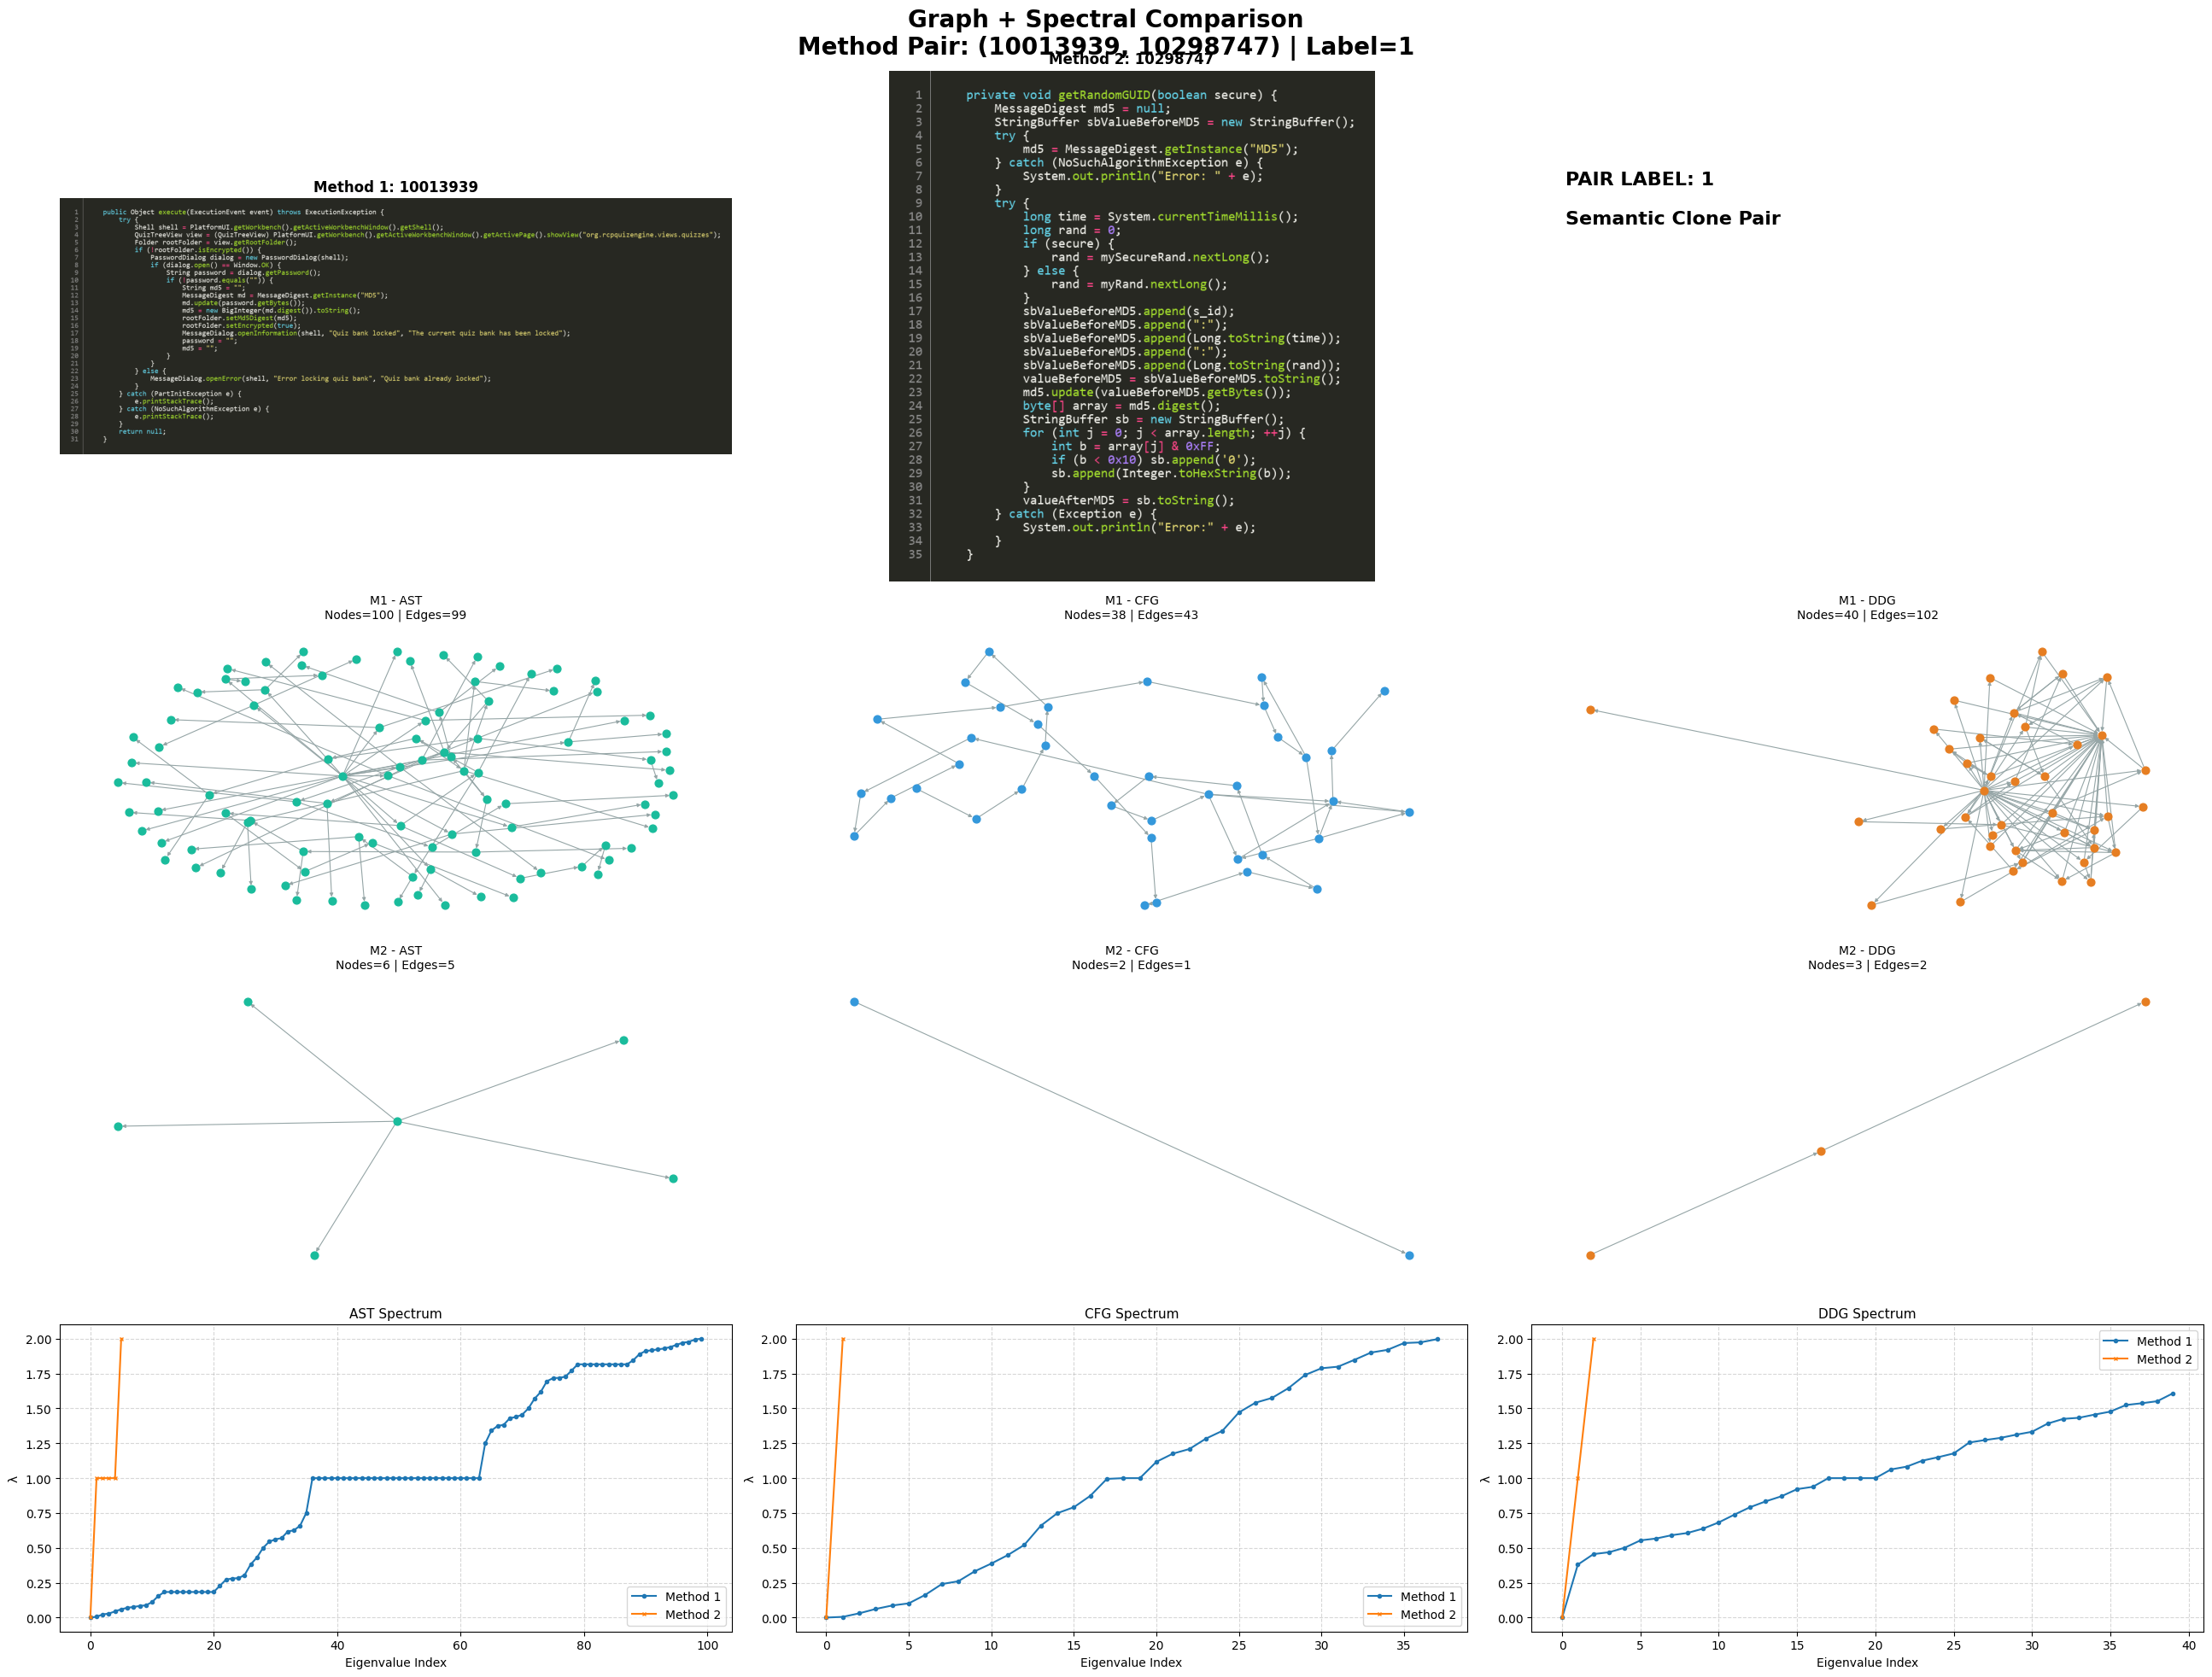

In [56]:
idx1 ='10013939'
idx2 = '10298747'
label = 1
visualize_method_pair(
    idx1,
    idx2,
    label,
    graph_db,
    features_db,
    code_map,
)

Selected Pair
Method 1: 10178931
Method 2: 10350952
Label    : 1


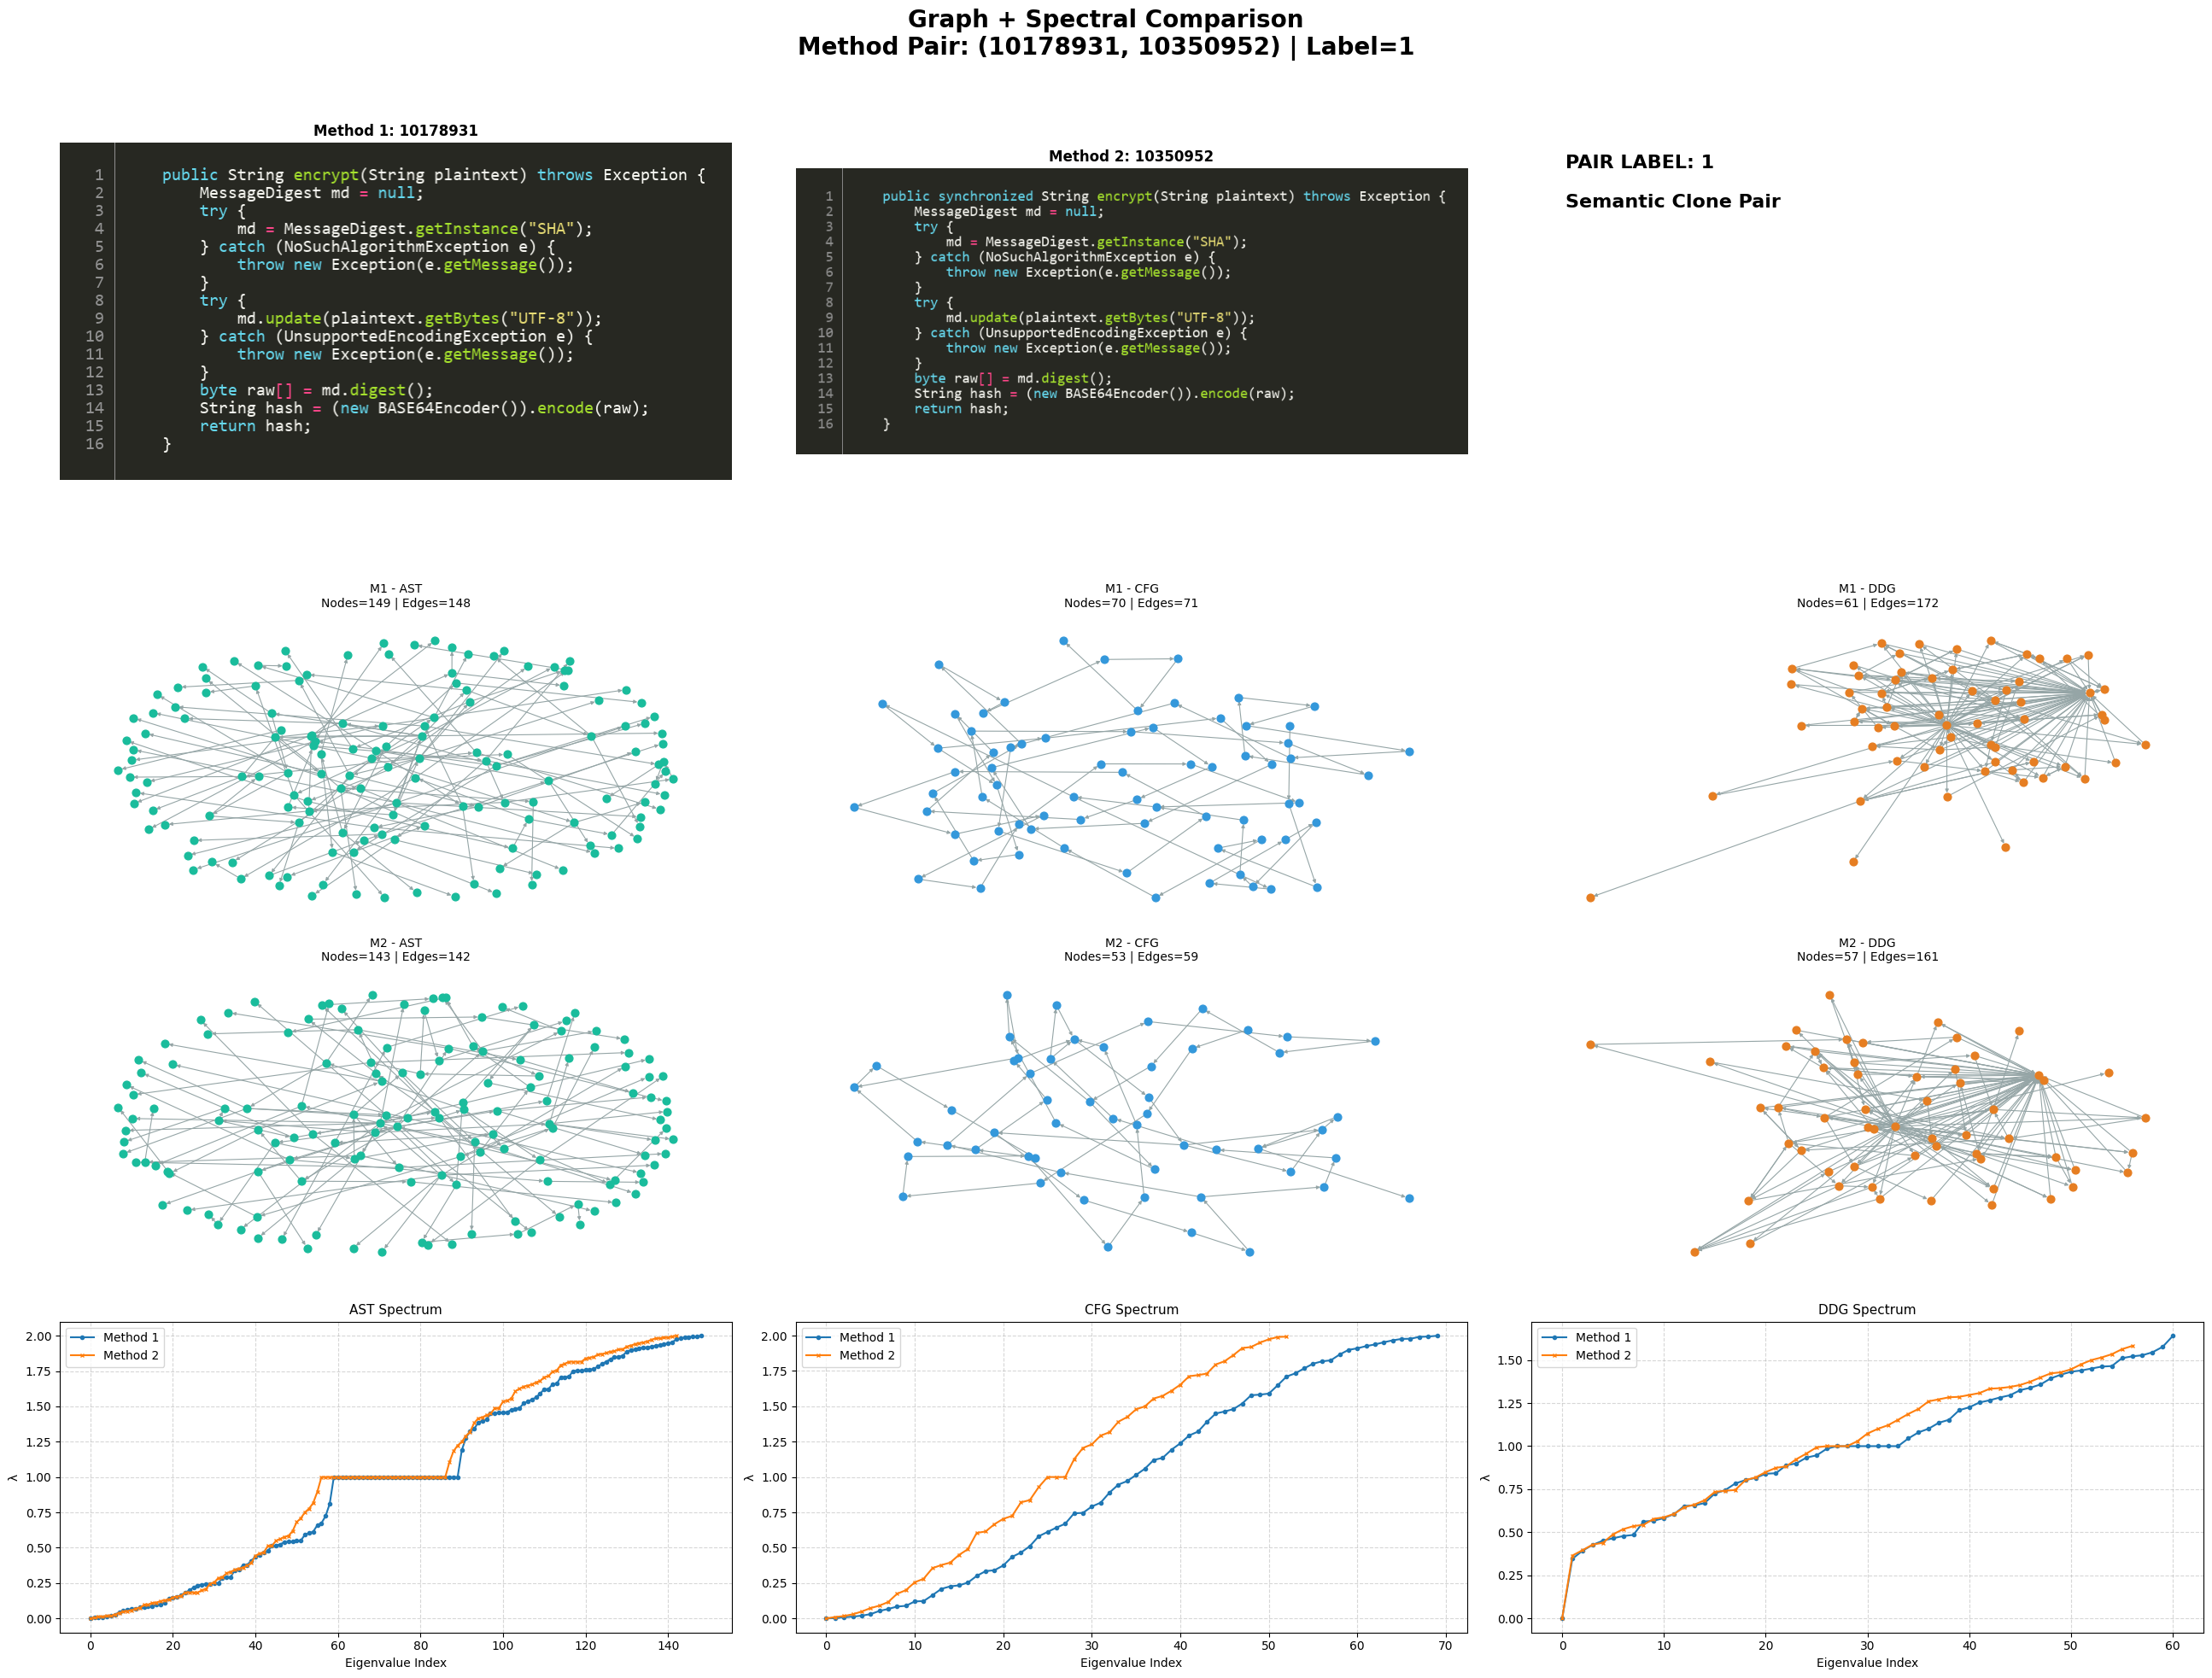

In [57]:
visualize_random_pair(
    train_pairs,
    graph_db,
    features_db,
    code_map,
)